---
## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Cross-validation & tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

print('All imports successful!')

All imports successful!


---
## 2. Load Data

In [4]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

# Combine for joint feature engineering
data_df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset columns:**
- `Survived` — target (0=Died, 1=Survived)
- `Pclass` — ticket class (1=Upper, 2=Middle, 3=Lower)
- `Name`, `Sex`, `Age`
- `SibSp` — # siblings/spouses aboard
- `Parch` — # parents/children aboard
- `Ticket`, `Fare`, `Cabin`
- `Embarked` — port (C=Cherbourg, Q=Queenstown, S=Southampton)

---
## 3. Initial Exploration (EDA)

**What is EDA?** Exploratory Data Analysis means looking at the data from many angles to understand its structure, find patterns, and form hypotheses before building a model.

**Key questions for Titanic:**
- Who survived? What patterns exist?
- Which features have missing values?
- How does each feature relate to survival?

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# Missing value analysis
missing     = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [9]:
# Overall survival rate
print(f"Overall survival rate: {train_df['Survived'].mean():.2%}")
print(f"Died: {(train_df['Survived']==0).sum()} | Survived: {(train_df['Survived']==1).sum()}")

Overall survival rate: 38.38%
Died: 549 | Survived: 342


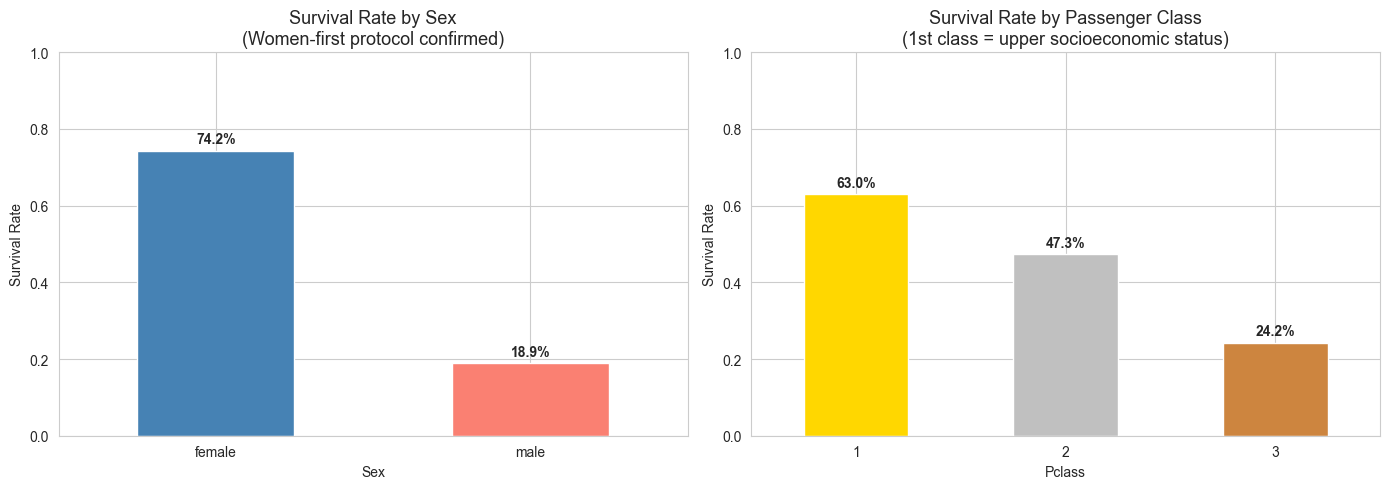

INSIGHT: Female survival 74% vs male 19% — Sex is the single strongest feature.
INSIGHT: 1st class survived at 63% vs 24% for 3rd class — wealth bought access to lifeboats.


In [11]:
# Survival by Sex and Pclass
# HYPOTHESIS: Women and children were prioritized ('women and children first' protocol)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_surv = train_df.groupby('Sex')['Survived'].mean()
sex_surv.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=0)
axes[0].set_title('Survival Rate by Sex\n(Women-first protocol confirmed)', fontsize=13)
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_surv):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

pclass_surv = train_df.groupby('Pclass')['Survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'peru'], rot=0)
axes[1].set_title('Survival Rate by Passenger Class\n(1st class = upper socioeconomic status)', fontsize=13)
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_surv):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("INSIGHT: Female survival 74% vs male 19% — Sex is the single strongest feature.")
print("INSIGHT: 1st class survived at 63% vs 24% for 3rd class — wealth bought access to lifeboats.")

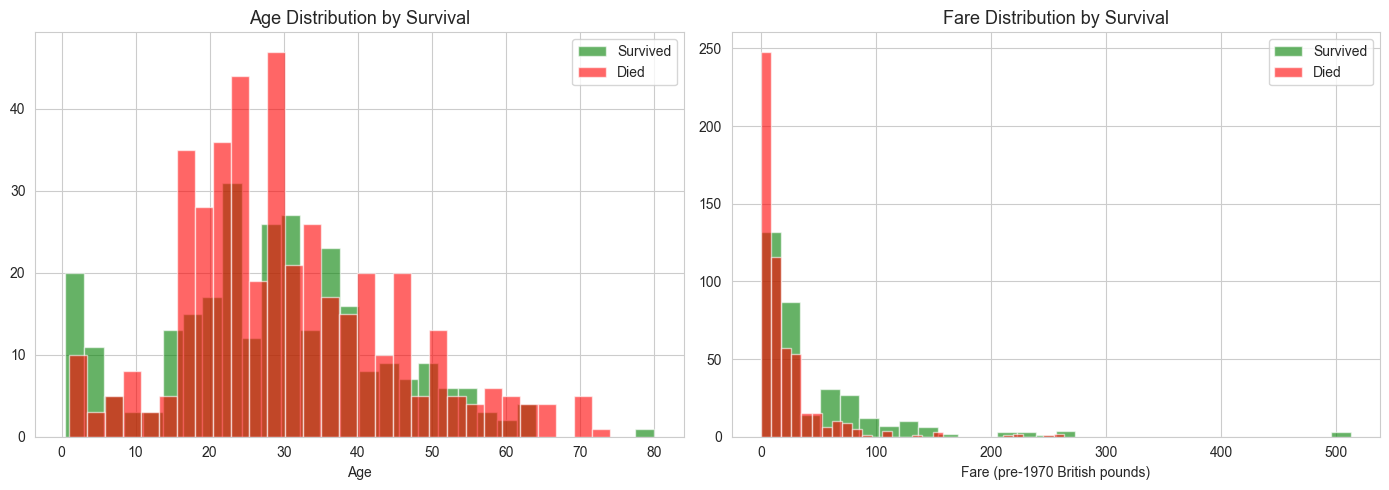

INSIGHT: Children under ~9 had notably higher survival — 'children first' in practice.
INSIGHT: Higher fare strongly correlates with survival — same information as Pclass but more granular.
INSIGHT: Age has 177 missing values — needs smart imputation.


In [12]:
# Age and Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df[train_df['Survived']==1]['Age'].dropna().hist(ax=axes[0], bins=30, alpha=0.6, color='green', label='Survived')
train_df[train_df['Survived']==0]['Age'].dropna().hist(ax=axes[0], bins=30, alpha=0.6, color='red',   label='Died')
axes[0].set_title('Age Distribution by Survival', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].legend()

train_df[train_df['Survived']==1]['Fare'].hist(ax=axes[1], bins=30, alpha=0.6, color='green', label='Survived')
train_df[train_df['Survived']==0]['Fare'].hist(ax=axes[1], bins=30, alpha=0.6, color='red',   label='Died')
axes[1].set_title('Fare Distribution by Survival', fontsize=13)
axes[1].set_xlabel('Fare (pre-1970 British pounds)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("INSIGHT: Children under ~9 had notably higher survival — 'children first' in practice.")
print("INSIGHT: Higher fare strongly correlates with survival — same information as Pclass but more granular.")
print(f"INSIGHT: Age has {train_df['Age'].isnull().sum()} missing values — needs smart imputation.")

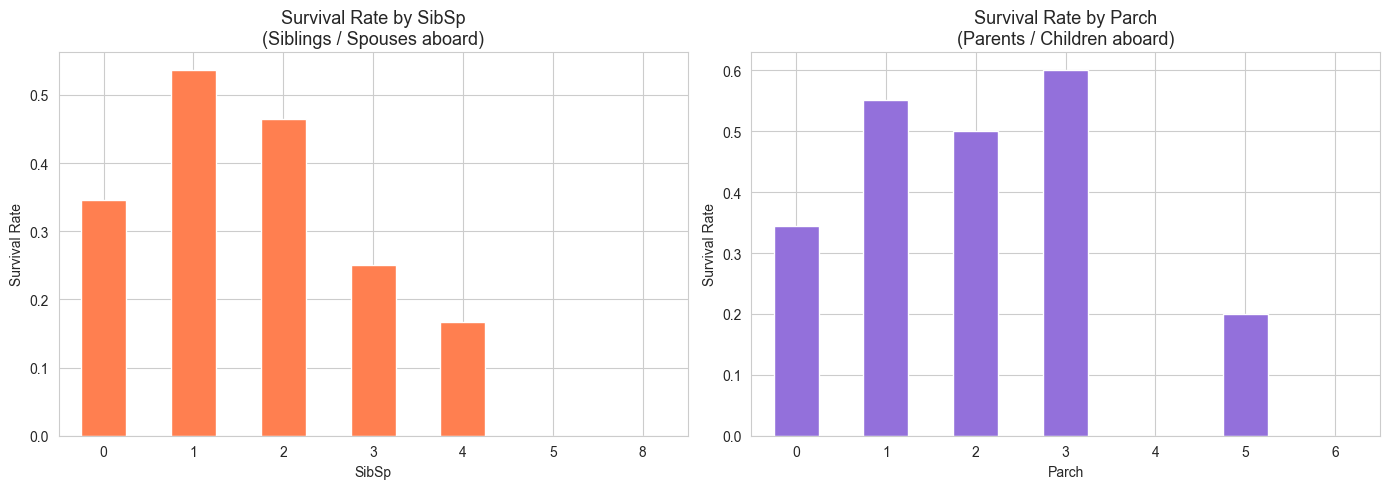

INSIGHT: Solo travelers (0 family) had lower survival — no one to help them find lifeboats.
INSIGHT: Small families (1–3) survived better. Very large families had coordination problems.
ACTION: Combine SibSp + Parch into a single Family_Size feature.


In [13]:
# Family features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], rot=0, color='coral')
axes[0].set_title('Survival Rate by SibSp\n(Siblings / Spouses aboard)', fontsize=13)
axes[0].set_ylabel('Survival Rate')

train_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], rot=0, color='mediumpurple')
axes[1].set_title('Survival Rate by Parch\n(Parents / Children aboard)', fontsize=13)
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

print("INSIGHT: Solo travelers (0 family) had lower survival — no one to help them find lifeboats.")
print("INSIGHT: Small families (1–3) survived better. Very large families had coordination problems.")
print("ACTION: Combine SibSp + Parch into a single Family_Size feature.")